### Plotting the photon and neutrino evolution following the BBN-simple paper


For more info on what are the formulae used and what was the process of this, refer to the research diary

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy import special as sps
import pandas as pd

In [4]:
# Defining them constants 

pi = np.pi

def exp(x):
    return np.exp(x)


## Masses ##
me = 0.510998 # Mass of electron in [MeV/c^2]
mp = 938.27208943 # Mass of proton in [MeV/c^2]
mn = 939.56542194 # Mass of neutron in [MeV/c^2]


Q = mn - mp # in [MeV/c^2]




## General Physical Units ##
G = 6.67e-45 # Gravitational Constant [MeV^-2] 
c = 2.99e10 # Speed of Light [cm/s]
kB = 8.617e-11 # Boltzmann Constant [MeV/Kelvin]
hbar = 6.582e-22 # Reduced Planck constant h/2pi [MeV s]
NA = 6.022e23 # Avogadro's number [# molecules/mole]


## Free Parameters ##
Neff = 3.046 # Number of neutrino flavors [unitless]
tau_n = 880 # Average lifetime of a neutron before decay [s]


def MeVtoK(T):
    'Converts T in MeV to T9'
    eV = 1/(8.619e-5) # 1 eV/kB to Kelvin
    MeV = eV*1e6 # Converting MeV to eV/kB
    K = MeV # Converting to Kelvin
    return K*T

In [5]:
# Defining the gaussian-laguerre quadrature integrator 

def gl_integrator(func):

    n = 64 
    roots, weights = sps.roots_laguerre(n)

    integrand = func(roots) * exp(roots) 

    integral = np.dot(integrand, weights)

    return integral


In [6]:
# Defining the functions that return the energy densities and pressure for different components of the early universe

def photon(T): 

    '''
    Returns the photon energy density, pressure 
    and the derivative of the energy density with 
    respect to temperature (evaluated at that temperature)
    at a given temperature (in MeV)
    
    '''

    # energy/mass density
    rho_gamma = (pi**2)/15 * T**4 

    # pressure 
    P_gamma = (1/3) * rho_gamma

    # drho_gamma/dT 
    drhog_dT = (4/T) * rho_gamma

    return rho_gamma, P_gamma, drhog_dT


def electron_positron(T): 
    
    '''
    Returns the electrons/positron energy/mass density, pressure 
    and the derivative of the energy density with 
    respect to temperature (evaluated at that temperature)
    at a given temperature (in MeV)
    
    '''

    # Defining the mass/energy density function's integrand

    def rho_e_integrand(x):

        y = me / T
        dist = np.sqrt(x**2 + y**2)

        integrand = (x**2 * dist) / (exp(dist) + 1)
        return integrand

    # Integrating the integrand and multiplying with the constants 
    rho_e = (2 / pi**2) * T**4 * gl_integrator(rho_e_integrand)

    

    # Defining the pressure function's integrand

    def P_e_integrand(x):

        y = me / T
        dist = np.sqrt(x**2 + y**2)

        integrand = x**4 / (dist * (exp(dist) + 1))
        return integrand 
    
    # Integrating the integrand and multiplying with the constants 
    P_e = (2 / (3 * pi**2)) * T**4 * gl_integrator(P_e_integrand)



    # Defining the drho/dT function's integrand

    def drho_dT_integrand(x): 

        y = me / T
        dist = np.sqrt(x**2 + y**2)

        integrand =  (x**2 * dist**2) / (exp(dist) + 1) * exp(dist) / (exp(dist) + 1)   # wrote in split format to prevent overflow issue
        return integrand 

    # Integrating the integrand and multiplying with the constants 
    drhoe_dT = (2 / pi**2) * T**3 * gl_integrator(drho_dT_integrand)

    return rho_e, P_e, drhoe_dT



def neutrino(Tnu):
    '''
    Returns the energy/mass density and pressure for the 
    neutrinos at a given temperature (in MeV)
    
    ''' 

    Neff = 3.046

    # energy density
    rhoneutrino =7/8*pi**2/15 *Neff* Tnu**4

    # pressure
    Pneutrino = rhoneutrino/3

    return rhoneutrino, Pneutrino


$$ \frac{d T}{d t} = - 3 H (\rho + P) \left( \frac{d \rho}{d T} \right)^{-1} $$

$$ \Rightarrow \frac{d t}{d T} = - \frac{1}{3 H (\rho + P)}  \left( \frac{d \rho}{d T} \right) $$

$$ \frac{d T_\nu}{d T} = \frac{T_\nu}{3 (\rho + P)} \frac{d \rho}{d T} $$

In [7]:
# Obtaining the time as a function of the temperature 

'''
We are taking this approach, where we find the age of the universe as a function of temperature instead of 
finding the temperature as the age of universe, because all our previously defined quantities are a direct function 
of the temperature (not time). 

So it would be better to take temperature as the independent quantity instead of time, and instead 
find the age of the universe as a function of time. 

Additionally we also find the neutrino temperature as a function of the photon temperature. Together we can calculate 
the relationship between the temperatures with time. 

'''


def T_dependence(T, state): 

    t, Tnu = state

    rhoe = electron_positron(T)[0]
    rhonu = neutrino(Tnu)[0]
    rhog = photon(T)[0]

    Pe = electron_positron(T)[1]
    Pnu = neutrino(Tnu)[1]
    Pg = photon(T)[1]

    drhoe_dT = electron_positron(T)[2]
    drhog_dT = photon(T)[2]
    
    H = np.sqrt(rhoe + rhonu + rhog) * np.sqrt(8*pi*G/3)/hbar

    rho_rad = rhog + rhoe
    P_rad = Pg + Pe
    drho_dT = drhoe_dT + drhog_dT

    # rho_rad = rhog + rhoe + rhonu
    # P_rad = Pg + Pe + Pnu
    # drho_dT = drhoe_dT + drhog_dT + 4*rhonu/T


    dt_dT = - (3 * H * (rho_rad + P_rad))**(-1) * drho_dT 

    dTnu_dT = Tnu / (3 * (rho_rad + P_rad)) * drho_dT

    return [dt_dT, dTnu_dT]

In [8]:
# Using the solve_ivp functionality to obtain the solutions for the DE 

Ti = 1e1
Tf = 1e-3
n =  1024
T = np.geomspace(Ti,Tf,n)

T_dependence_solution = sp.integrate.solve_ivp(fun = T_dependence, t_span = T[[0,-1]], y0 = [0, Ti], t_eval = T)
t = T_dependence_solution.y[0]
Tnu = T_dependence_solution.y[1]

Testing the formula obtained from Weinberg for the neutrino temperature

In [68]:
# Defining the neutrino temperature obtained from Weinberg's relation

def Tnu_weinberg_formula(T):    # input the photon tempearture in MeV 

    y = me / T 

    def S_integrand(x):

        dist = np.sqrt(x**2 + y**2)
        
        return 45/(2 * pi**4) * (x**2)/(exp(dist) + 1) * ( dist + x**2 / (3 * dist) )  
    
    S_integrated = gl_integrator(S_integrand)

    return T * ( (4/11) * (1 + S_integrated) )**(1/3)

# Calculate the neutrino temperature using the Weinberg formula

Tnu_weinberg = np.array([Tnu_weinberg_formula(temp) for temp in T])

In [ ]:
# Since we have T(t), Tnu(t) or t(T), Tnu(T) 
# i.e. the temperatures are a either a function of time or 
# the neutrino temperature and time are a function of the gamma temperature 

# We can instead define them all inside a dictionary which would make it easy to access them later on 
# Instead of using indices to access them, we can just get their direct values instead, when we want to access individual values

func_of_t = {}  # T and Tnu (in that order) as a function of time

func_of_T = {}  # t and Tnu (in that order) as a function of time


for i in range(len(T)): 

    func_of_t.update({t[i]: [T[i], Tnu[i]]})

    func_of_T.update({T[i]: [t[i], Tnu[i]]})

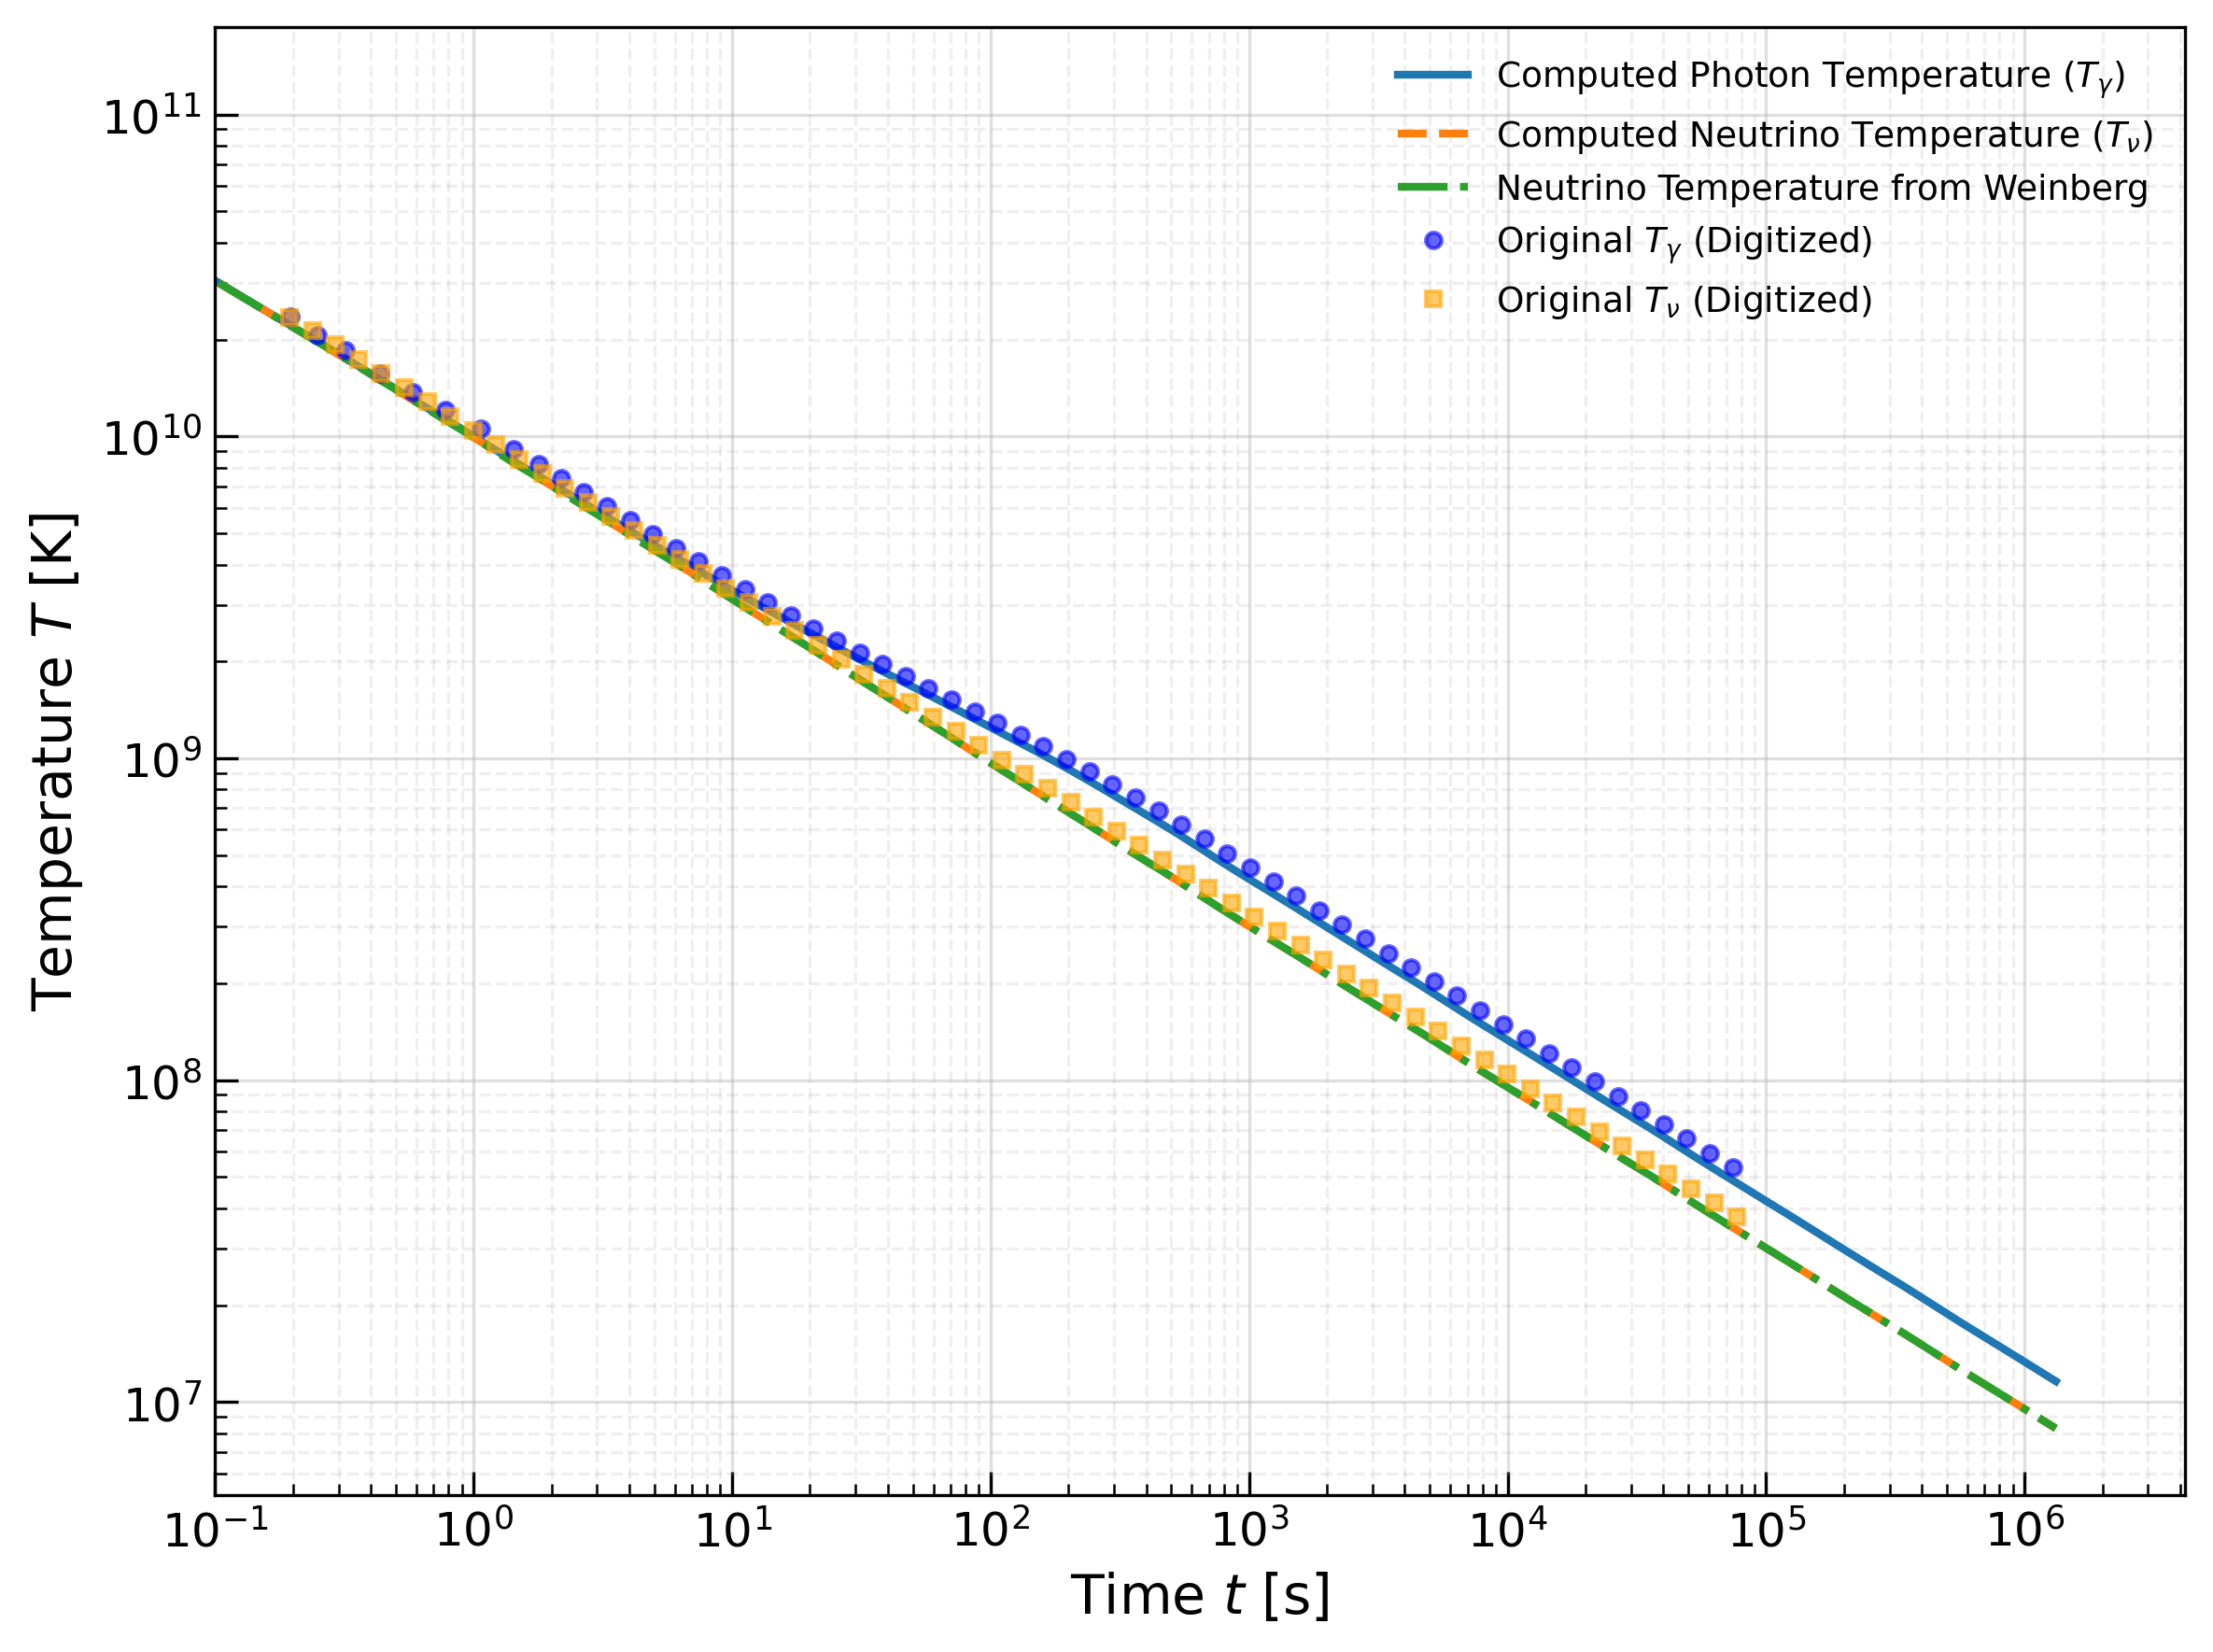

In [11]:
# Load digitized data from CSV files
T_nu_digitized = np.loadtxt('digitized-plots/BBN-simple-plots/Tnu-and-Tgamma/T-nu.csv', delimiter=',')
T_gamma_digitized = np.loadtxt('digitized-plots/BBN-simple-plots/Tnu-and-Tgamma/T-gamma.csv', delimiter=',')

# Plotting the evolution of photon and neutrino temperatures

# Create a figure with a standard scientific aspect ratio
plt.figure(figsize=(8, 6), dpi=300)

# Plot the computed temperatures
plt.loglog(t, MeVtoK(T), label=r'Computed Photon Temperature ($T_\gamma$)', linewidth=2)
plt.loglog(t, MeVtoK(Tnu), label=r'Computed Neutrino Temperature ($T_\nu$)', linewidth=2, linestyle='--')
plt.loglog(t, MeVtoK(temp_nu), label=r'Neutrino Temperature from Weinberg', linewidth=2, linestyle='-.')

# Plot the digitized original data (multiplying by 1e9 since digitized data is in T9)
plt.loglog(T_gamma_digitized[:, 0], 1e9 * T_gamma_digitized[:, 1], 'o', label=r'Original $T_\gamma$ (Digitized)', markersize=4, alpha=0.6, color='blue')
plt.loglog(T_nu_digitized[:, 0], 1e9 * T_nu_digitized[:, 1], 's', label=r'Original $T_\nu$ (Digitized)', markersize=4, alpha=0.6, color='orange')

# Axis limits and labels
plt.xlim(left=0.1) # Keeping your lower limit constraint
plt.xlabel(r'Time $t$ [s]', fontsize=14)
plt.ylabel(r'Temperature $T$ [K]', fontsize=14)

# Tick parameters for paper-quality
plt.tick_params(axis='both', which='major', labelsize=12, length=6, direction='in')
plt.tick_params(axis='both', which='minor', length=3, direction='in')

# Add grid lines for easier reading on a log-log plot
plt.grid(True, which="major", ls="-", alpha=0.4)
plt.grid(True, which="minor", ls="--", alpha=0.2)

# Legend without an intrusive frame
plt.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.show()


---

### Weak interaction rates and neutrino decoupling 

In [12]:
# Function which calculates the weak interaction rates 

def WeakRate(T, Tnu):

    # Setting up the necessary constants and parameters 
    q = Q/me
    z = me/T
    z_nu = me/Tnu

    def K_integrand(x):   # The T = 0 limit of the lambda function, which is used to find the normalization factor K

        return  x * (x - q)**2 * np.sqrt(x**2 - 1)

    K_integral = sp.integrate.quad(K_integrand, 1, q)[0]

    K = (1/tau_n) * 1/K_integral

    
    # Writing out the reaction rates 
    def integrand_1(x): 

        x = x + 1   # performing a change of variables so that the limits of integration becomes 0 to inf

        numerator = x * (x+q)**2 * np.sqrt(x**2 - 1)
        denominator = (1 + exp(x*z)) * ( 1 + exp(-(x+q) * z_nu) )

        return numerator/denominator

    def integrand_2(x): 

        x = x + 1   # performing a change of variables so that the limits of integration becomes 0 to inf

        numerator = x * (x-q)**2 * np.sqrt(x**2 - 1)
        denominator = (1 + exp(-x*z)) * ( 1 + exp((x-q) * z_nu) )
        
        return numerator/denominator

    
    # Performing the integral using the GL quadrature 
    integral_1 = gl_integrator(integrand_1)
    integral_2 = gl_integrator(integrand_2)


    # Final reaction rate for n -> p 
    lambda_np = K * (integral_1 + integral_2)



    # For the reverse process, we just need to flip the sign of q and proceed the same way

    q = - q 

    # Performing the integrals 
    rev_integral_1 = gl_integrator(integrand_1)
    rev_integral_2 = gl_integrator(integrand_2)

    # Final reaction rate for p -> n 
    lambda_pn = K * (rev_integral_1 + rev_integral_2)


    return lambda_np, lambda_pn



In [ ]:
# Calculating and plotting the weak interaction rates 

lambda_n2p = []
lambda_p2n = []

for i in range(len(T)):
    rate = WeakRate(T[i], Tnu[i])
    lambda_n2p.append(rate[0])
    lambda_p2n.append(rate[1]) 

    # also adding them to the dictionaries 

    func_of_T[T[i]].append(rate[0])
    func_of_T[T[i]].append(rate[1])

    func_of_t[t[i]].append(rate[0])
    func_of_t[t[i]].append(rate[1])

lambda_n2p = np.array(lambda_n2p)
lambda_p2n = np.array(lambda_p2n)


# Creating functions for the rates as a function of time

n2p_rate = sp.interpolate.interp1d(t, lambda_n2p, kind= "cubic")
p2n_rate = sp.interpolate.interp1d(t, lambda_p2n, kind= "cubic")


/tmp/ipykernel_5565/2892355978.py:6: RuntimeWarning: overflow encountered in exp
  return np.exp(x)
/tmp/ipykernel_5565/3523059434.py:25: RuntimeWarning: overflow encountered in multiply
  denominator = (1 + exp(x*z)) * ( 1 + exp(-(x+q) * z_nu) )


The dictionaries, `func_of_t` and `func_of_T` repsectively now read: 

$$ \text{func\_of\_t} = \{ t: \; T, \; T_\nu, \; \lambda_{n \rightarrow p}, \; \lambda_{p \rightarrow n} \} $$

$$ \text{func\_of\_t} = \{ T: \; t, \; T_\nu, \; \lambda_{n \rightarrow p}, \; \lambda_{p \rightarrow n} \} $$

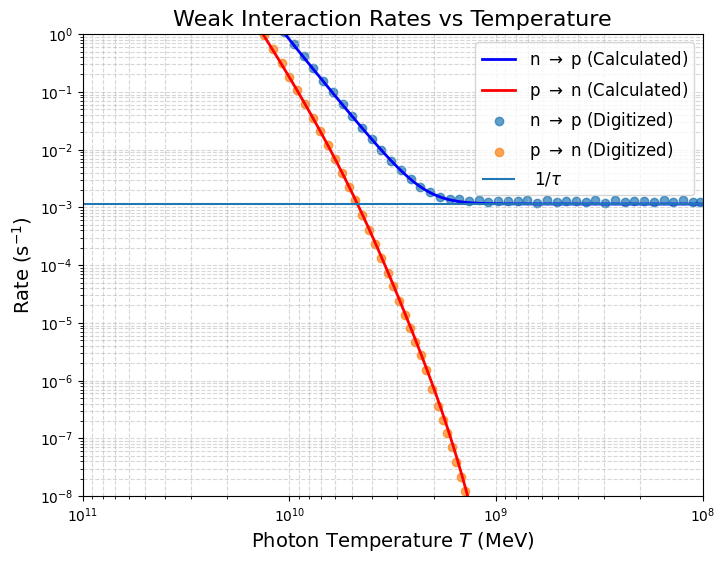

In [14]:

# Read the digitized data for comparison
n2p_data = pd.read_csv('digitized-plots/BBN-simple-plots/Weak-rates/n2p.csv', header=None, names=['T', 'Rate'])
p2n_data = pd.read_csv('digitized-plots/BBN-simple-plots/Weak-rates/p2n.csv', header=None, names=['T', 'Rate'])

fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot our numerical results
ax1.plot(MeVtoK(T), lambda_n2p, 'b-', label='n $\\rightarrow$ p (Calculated)', linewidth=2)
ax1.plot(MeVtoK(T), lambda_p2n, 'r-', label='p $\\rightarrow$ n (Calculated)', linewidth=2)

# Plot the digitized data for comparison
ax1.scatter(n2p_data['T'] * 1e9, n2p_data['Rate'], label='n $\\rightarrow$ p (Digitized)', alpha=0.7)
ax1.scatter(p2n_data['T'] * 1e9, p2n_data['Rate'], label='p $\\rightarrow$ n (Digitized)', alpha=0.7)

# Adding a dashed line representing the asymptotic limit 

ax1.hlines(1/tau_n, xmin=1e11, xmax=1e8, label=' $1/\\tau$')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Photon Temperature $T$ (MeV)', fontsize=14)
ax1.set_ylabel('Rate (s$^{-1}$)', fontsize=14)
ax1.set_title('Weak Interaction Rates vs Temperature', fontsize=16)

# Reverse the x-axis so that high temp (early times) are on the left
ax1.set_xlim(1e11, 1e8)
ax1.set_ylim(1e-8, 1e0)

ax1.legend(fontsize=12)
ax1.grid(True, which="both", ls="--", alpha=0.5)


plt.show()


$$ \frac{d X_n}{dt} = \lambda_{p \rightarrow n} X_n - \lambda_{n \rightarrow p} X_p $$
$$ \frac{d X_p}{dt} = \lambda_{n \rightarrow p} X_p - \lambda_{p \rightarrow n} X_n $$

Doing, a chain rule substitution, we get:

$$ \frac{d X}{dt} = \frac{d X}{dT}  \frac{dT}{dt} $$

Substituting this back, we get: 

$$ \frac{d X_n}{dT} = \left( \lambda_{p \rightarrow n} X_n - \lambda_{n \rightarrow p} X_p \right) \cdot \frac{dt}{dT} $$
$$ \frac{d X_p}{dT} = \left( \lambda_{n \rightarrow p} X_p - \lambda_{p \rightarrow n} X_n \right) \cdot \frac{dt}{dT} $$

So we get a system of coupled differential equations, which we solve below

In [105]:
# Calculating the evolution of the abundances of protons and neutrons over time(temperature)

def n_p_abundance(T, state): 

    t, Tnu, X_n, X_p = state 

    # Some constants 

    lambda_n2p = WeakRate(T, Tnu)[0]
    lambda_p2n = WeakRate(T, Tnu)[1]

    rhoe = electron_positron(T)[0]
    rhonu = neutrino(Tnu)[0]
    rhog = photon(T)[0]

    Pe = electron_positron(T)[1]
    Pnu = neutrino(Tnu)[1]
    Pg = photon(T)[1]

    drhoe_dT = electron_positron(T)[2]
    drhog_dT = photon(T)[2]
    
    H = np.sqrt(rhoe + rhonu + rhog) * np.sqrt(8*pi*G/3)/hbar

    rho_rad = rhog + rhoe
    P_rad = Pg + Pe
    drho_dT = drhoe_dT + drhog_dT

    # the differential eqns

    dt_dT = - (3 * H * (rho_rad + P_rad))**(-1) * drho_dT 

    dTnu_dT = Tnu / (3 * (rho_rad + P_rad)) * drho_dT

    dXn_dT = ( lambda_p2n * X_p - lambda_n2p * X_n ) * dt_dT 

    dXp_dT = ( lambda_n2p * X_n - lambda_p2n * X_p ) * dt_dT

    return [dt_dT, dTnu_dT, dXn_dT, dXp_dT]


# Solving the system of D.E's

abundance = sp.integrate.solve_ivp(fun= n_p_abundance_2, t_span= T[[0, -1]], y0= [0, Ti, 0.5, 0.5], t_eval= T)
t = abundance.y[0]
Tnu = abundance.y[1]
X_n = abundance.y[2]
X_p = abundance.y[3]

/tmp/ipykernel_5565/2892355978.py:6: RuntimeWarning: overflow encountered in exp
  return np.exp(x)
/tmp/ipykernel_5565/3523059434.py:25: RuntimeWarning: overflow encountered in multiply
  denominator = (1 + exp(x*z)) * ( 1 + exp(-(x+q) * z_nu) )


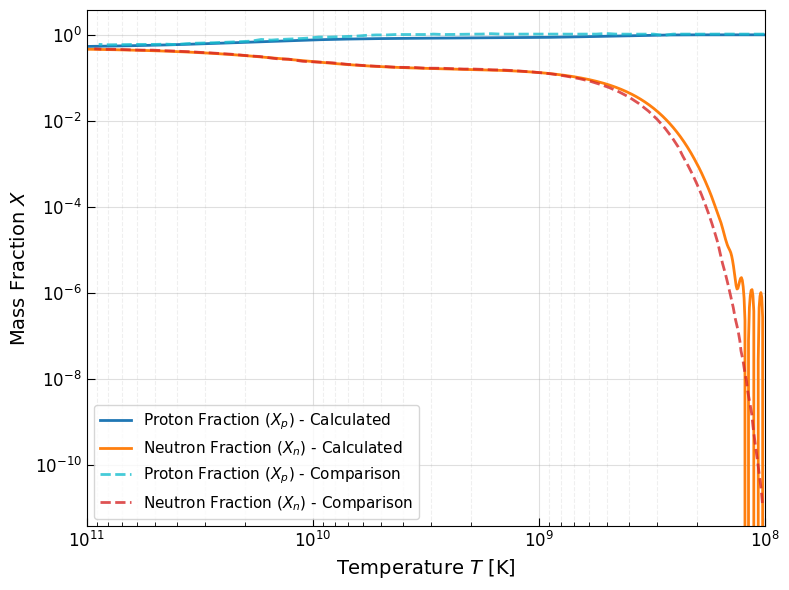

In [110]:
# Calculating the evolution of the abundances of protons and neutrons over time(temperature)

# Load the digitized comparison data from the provided CSV files
Xn_data = np.loadtxt('digitized-plots/BBN-simple-plots/n-p-fraction-evolution/Xn.csv', delimiter=',')
Xp_data = np.loadtxt('digitized-plots/BBN-simple-plots/n-p-fraction-evolution/Xp.csv', delimiter=',')

# Create a figure with a standard scientific aspect ratio
plt.figure(figsize=(8, 6))

# Plot your calculated abundance evolution
plt.loglog(MeVtoK(T), X_p, label=r'Proton Fraction ($X_p$) - Calculated', linewidth=2, color='tab:blue')
plt.loglog(MeVtoK(T), X_n, label=r'Neutron Fraction ($X_n$) - Calculated', linewidth=2, color='tab:orange')

# Overlay the digitized comparison data
plt.loglog(Xp_data[:, 0], Xp_data[:, 1], label=r'Proton Fraction ($X_p$) - Comparison', 
           linewidth=2, linestyle='--', color='tab:cyan', alpha=0.8)
plt.loglog(Xn_data[:, 0], Xn_data[:, 1], label=r'Neutron Fraction ($X_n$) - Comparison', 
           linewidth=2, linestyle='--', color='tab:red', alpha=0.8)

# Axis limits and labels
plt.xlim(1e11, 1e8)  # Reversing x-axis to show temperature dropping from left to right
# plt.ylim(1e-11, 2) # You can uncomment this if you want to bound the y-axis explicitly

plt.xlabel(r'Temperature $T$ [K]', fontsize=14)
plt.ylabel(r'Mass Fraction $X$', fontsize=14)

# Tick parameters for paper-quality
plt.tick_params(axis='both', which='major', labelsize=12, length=6, direction='in')
plt.tick_params(axis='both', which='minor', length=3, direction='in')

# Add grid lines for easier reading on a log-log plot
plt.grid(True, which="major", ls="-", alpha=0.4)
plt.grid(True, which="minor", ls="--", alpha=0.2)

# Legend without an intrusive frame
plt.legend(fontsize=11, frameon=True, loc='best')

plt.tight_layout()
plt.show()
